In [79]:
import lseg.data as ld
from lseg.data.errors import LDError
import numpy as np
import calendar
import cufflinks as cf
import pandas as pd
from pandas.tseries.offsets import BMonthEnd
from datetime import datetime
import os

cf.go_offline()

app_key = os.environ['APP_KEY']
ld.open_session(app_key=app_key)

def current_month():
    return datetime.now().month

def sys_year():
    today_date = datetime.strptime(datetime.today().strftime('%Y-%m-%d'), '%Y-%m-%d')
    y = str(today_date.year)[-2:]
    return y

def last_workday(d):
    last = BMonthEnd()
    return last.rollforward(d)

def eom(y, m):
    ed = last_workday(datetime(year = int(y), month=m, day=1)).strftime('%Y-%m-%d')
    return ed

def som(y, m):
    sd = datetime(year = int(y), month=m, day=1).strftime('%Y-%m-%d')
    return sd

def gen_contracts(r, d, m):
    xd = ld.get_data(r, 'EXPIR_DATE')   
    xd = xd['EXPIR_DATE'][0]
    xd = xd.strftime('%Y-%m-%d').split('-')
    y = xd[0]
    _m = int(xd[1]) if m is None else m
    _y = int(y)
    _x = []
    x = []
    root = contract_data(r)
    while d >= 0:
        if d == 0:
            _x = ('{}{}'.format(root, str(_y - d)[-1:]))
            _ed = eom(_y-d, _m)
        else:
            dec = str(_y - d)[-2:][0]
            _x = '{}{}^{}'.format(root, str(_y - d)[-1], dec)
            _ed = eom(_y-d, _m)
        _sd = som(_y-d, _m)
        x.append([_x, _sd, _ed])
        d -= 1    
    return x

def contract_data(r):
    k = list(r)
    root = ''.join(k[:-1])
    return root

def get_timeseries_seq(l):
    d = {}
    for i in l:        
        try:
            df_tmp = ld.get_history(i[0], ['TRDPRC_1'], start=i[1], end=i[2], interval='daily')
            if df_tmp.empty == False:                
                d[i[0]] = df_tmp
                d[i[0]].columns.values[0] = i[0]
        except LDError as err:
             print(str(err.code)+" "+err.message)
            
        
    return d

def get_data(ric, lookback_years = 5, month = current_month(), rebase = False):
    if 'c' in ric:
        return 'Please enter a futures delivery month contract code (e.g. LCOK0).'
    
    frames = gen_contracts(ric, lookback_years, month)
    hist = get_timeseries_seq(frames)
    
    for k in hist.keys():
        _idx = []
        for i in range(len(hist[k])):
            _idx.append(list(hist[k].index)[i].strftime('%b-%d'))
        hist[k]['Dates'] = _idx
    
    seasonal_df = pd.DataFrame(columns = ['Dates'])   
    for k in hist.keys():
        seasonal_df = pd.merge(seasonal_df, hist[k], on='Dates', how = 'outer')
        
    
    seasonal_df = seasonal_df.sort_values(by='Dates')
    seasonal_df = seasonal_df.fillna(method='backfill')
    seasonal_df = seasonal_df.reset_index(drop = True)
    seasonal_df.index = seasonal_df['Dates']
    seasonal_df = seasonal_df.drop(columns='Dates')
    seasonal_df.columns = list(hist.keys())
    title = 'Seasonality chart'
    ytitle = 'Price'

    
    if seasonal_df.empty:
        return seasonal_df
        
    if rebase:
        seasonal_df = pd.DataFrame((np.log(seasonal_df)-np.log(seasonal_df.iloc[0])))*100
        title = 'Rebased seasonality chart'
        ytitle = 'Change, %'       
    
    display(seasonal_df.dropna().iplot(title=title, yTitle = ytitle))
    return seasonal_df.dropna()



In [80]:
gen_contracts('LCOM5',10,4)

[['LCOM5^1', '2015-04-01', '2015-04-30'],
 ['LCOM6^1', '2016-04-01', '2016-04-29'],
 ['LCOM7^1', '2017-04-01', '2017-04-28'],
 ['LCOM8^1', '2018-04-01', '2018-04-30'],
 ['LCOM9^1', '2019-04-01', '2019-04-30'],
 ['LCOM0^2', '2020-04-01', '2020-04-30'],
 ['LCOM1^2', '2021-04-01', '2021-04-30'],
 ['LCOM2^2', '2022-04-01', '2022-04-29'],
 ['LCOM3^2', '2023-04-01', '2023-04-28'],
 ['LCOM4^2', '2024-04-01', '2024-04-30'],
 ['LCOM5', '2025-04-01', '2025-04-30']]

C:\Users\U8009686\AppData\Local\Temp\ipykernel_44932\2958709657.py:97:FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.


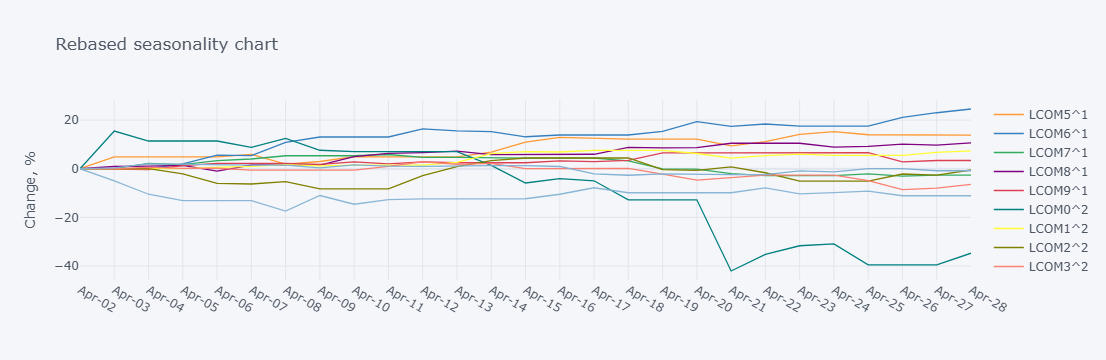

None

In [81]:
ric = 'LCOM5'
lookback_years = 10
month = 4
rebase = True
df = get_data(ric, lookback_years, month, rebase)
